### Antiviral QSAR with MACAW (https://github.com/LBLQMM/MACAW)
Uses low-dimensional MACAW embeddings (macaw_*) + physchem features to:
  - Regress pPotency
  - Classify "active" (value_uM <= threshold)
  - Evaluate on a scaffold-aware split

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report
)

In [11]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')

In [12]:
# Config
allBacteriaData_chEMBL_wMACAW = pd.read_csv(os.path.join(modelBuildingDataDir, "allBacteriaData_chEMBL_uM_wMACAW.csv"))
activityThresholdUm = 1.0   # "active" if value_uM <= threshold (try 1–10 µM)
randomState = 42

In [13]:
allBacteriaData_chEMBL_wMACAW.shape

(162378, 47)

### Add some randomization to the data

In [8]:
allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW.sample(frac=1, random_state=42).reset_index(drop=True)

totalRows: 162378
exactPPotencyRows: 162378
activeRows(≤1.0µM): 65319
featureBlocks: macawDims=15, physchemDims=10, totalDims=25

[train] pPotency regression
r2: 0.7429
rmse: 22.8179
mae: 9.7049

[test] pPotency regression
r2: 0.1960
rmse: 36.5155
mae: 21.7496


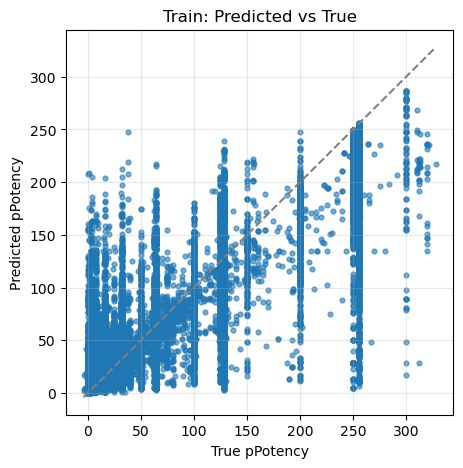

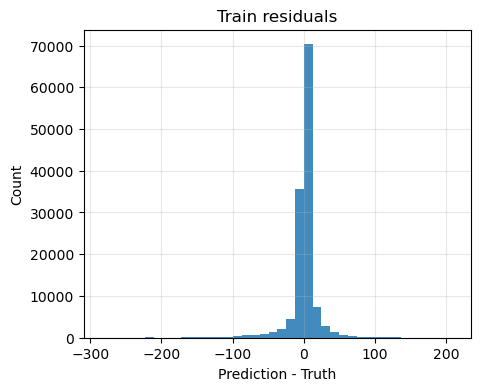

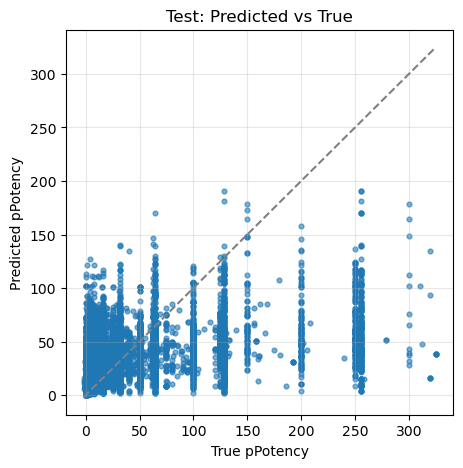

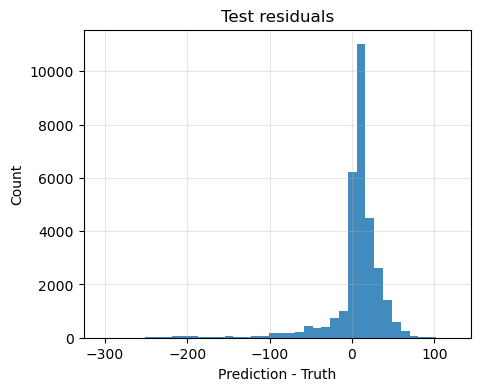


activityThresholdUm: ≤1.0 µM
trainRocAuc: 0.628 trainPrAuc: 0.536
testRocAuc : 0.650 testPrAuc : 0.547

classificationReport (test):
              precision    recall  f1-score   support

           0      0.712     0.675     0.693     19371
           1      0.510     0.552     0.530     11847

    accuracy                          0.629     31218
   macro avg      0.611     0.614     0.612     31218
weighted avg      0.635     0.629     0.631     31218



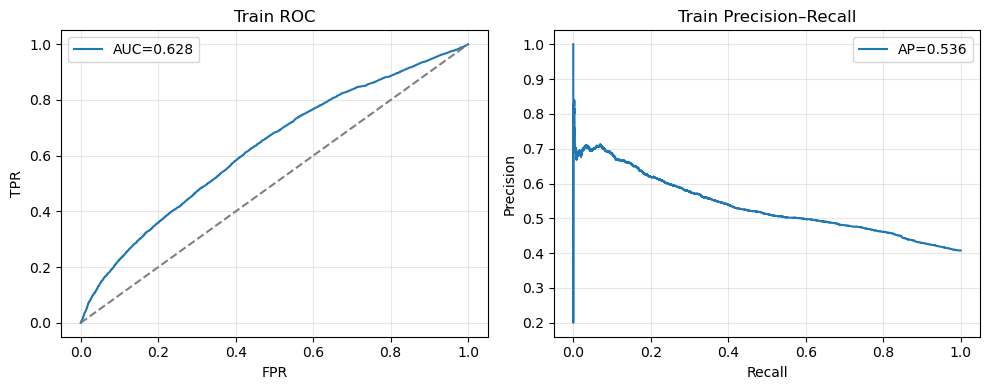

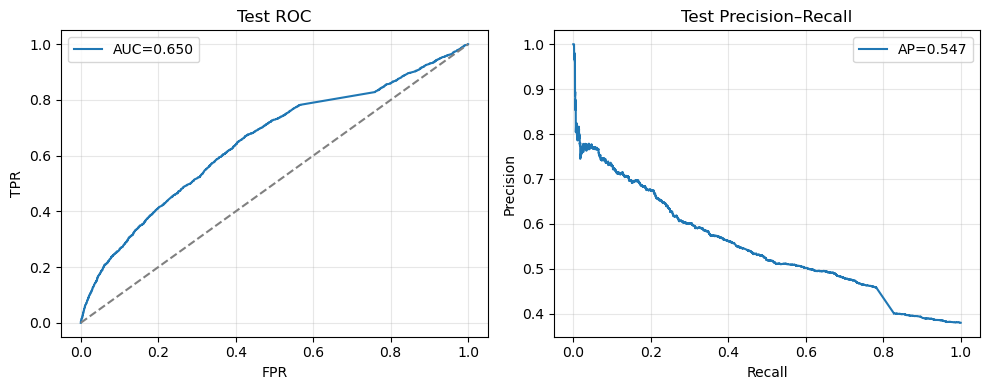

In [14]:
# Hygiene: drop index artifacts if present
if "Unnamed: 0" in allBacteriaData_chEMBL_wMACAW.columns:
    allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW.drop(columns=["Unnamed: 0"])

requiredCols = {"smiles", "pPotency", "value_uM"}
missingCols = [c for c in requiredCols if c not in allBacteriaData_chEMBL_wMACAW.columns]
if missingCols:
    raise ValueError(f"Missing required columns: {missingCols}")

# Some CSVs may not carry invalidSmiles; rebuild if missing
if "invalidSmiles" not in allBacteriaData_chEMBL_wMACAW.columns:
    def isValidSmiles(s):
        if not isinstance(s, str) or not s: 
            return False
        try:
            return Chem.MolFromSmiles(s) is not None
        except Exception:
            return False
    allBacteriaData_chEMBL_wMACAW["invalidSmiles"] = ~allBacteriaData_chEMBL_wMACAW["smiles"].astype(str).apply(isValidSmiles)

# Keep valid SMILES
allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW[
    allBacteriaData_chEMBL_wMACAW["smiles"].notna() & (~allBacteriaData_chEMBL_wMACAW["invalidSmiles"].fillna(True))
].copy()

# Physchem columns (create if missing to keep matrix shapes aligned)
physCols = [
    "molecular_weight","AlogP","polar_surface_area","hba","hbd",
    "rotatable_bonds","qed_weighted","heavy_atoms","aromatic_rings","ro5_violations"
]
for col in physCols:
    if col not in allBacteriaData_chEMBL_wMACAW.columns:
        allBacteriaData_chEMBL_wMACAW[col] = np.nan
allBacteriaData_chEMBL_wMACAW[physCols] = allBacteriaData_chEMBL_wMACAW[physCols].apply(pd.to_numeric, errors="coerce")

# Labels
allBacteriaData_chEMBL_wMACAW["isExactPotency"] = allBacteriaData_chEMBL_wMACAW["pPotency"].notna()
allBacteriaData_chEMBL_wMACAW["isActive"] = pd.to_numeric(allBacteriaData_chEMBL_wMACAW["value_uM"], errors="coerce") <= activityThresholdUm

print(f"totalRows: {len(allBacteriaData_chEMBL_wMACAW)}")
print(f"exactPPotencyRows: {int(allBacteriaData_chEMBL_wMACAW['isExactPotency'].sum())}")
print(f"activeRows(≤{activityThresholdUm}µM): {int(allBacteriaData_chEMBL_wMACAW['isActive'].sum())}")

# ---------------------------
# Features: MACAW + physchem
# ---------------------------
macawCols = [c for c in allBacteriaData_chEMBL_wMACAW.columns if c.startswith("macaw_")]
if not macawCols:
    raise ValueError("No MACAW columns found (expected columns starting with 'macaw_').")

XMacaw = allBacteriaData_chEMBL_wMACAW[macawCols].to_numpy()
XPhys  = allBacteriaData_chEMBL_wMACAW[physCols].fillna(0.0).to_numpy()
XAll   = np.hstack([XMacaw, XPhys])

print("featureBlocks:",
      f"macawDims={XMacaw.shape[1]}, physchemDims={XPhys.shape[1]}, totalDims={XAll.shape[1]}")

# ---------------------------
# Scaffold-aware split
# ---------------------------
def smilesToScaffold(smi: str) -> str:
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return ""
        core = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(core) if core is not None else ""
    except Exception:
        return ""

allBacteriaData_chEMBL_wMACAW["scaffold"] = allBacteriaData_chEMBL_wMACAW["smiles"].astype(str).apply(smilesToScaffold)

rng = np.random.RandomState(randomState)
uniqueScaffolds = pd.Series(allBacteriaData_chEMBL_wMACAW["scaffold"].fillna("").unique())
rng.shuffle(uniqueScaffolds.values)

cut = int(0.8 * len(uniqueScaffolds))
trainScaffolds = set(uniqueScaffolds.iloc[:cut])
testScaffolds  = set(uniqueScaffolds.iloc[cut:])

trainIdx = allBacteriaData_chEMBL_wMACAW["scaffold"].isin(trainScaffolds).to_numpy()
testIdx  = allBacteriaData_chEMBL_wMACAW["scaffold"].isin(testScaffolds).to_numpy()

# ---------------------------
# Helpers: metrics/plots
# ---------------------------
def rmse(yTrue, yPred):
    return np.sqrt(mean_squared_error(yTrue, yPred))

def summarizeReg(yTrue, yPred, tag):
    print(f"\n[{tag}] pPotency regression")
    print(f"r2: {r2_score(yTrue, yPred):.4f}")
    print(f"rmse: {rmse(yTrue, yPred):.4f}")
    print(f"mae: {mean_absolute_error(yTrue, yPred):.4f}")

def plotPredVsTrue(yTrue, yPred, title):
    yTrue = np.asarray(yTrue); yPred = np.asarray(yPred)
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(yTrue, yPred, s=12, alpha=0.6)
    lo = float(np.nanmin([yTrue.min(), yPred.min()]))
    hi = float(np.nanmax([yTrue.max(), yPred.max()]))
    ax.plot([lo, hi], [lo, hi], '--', color='gray')
    ax.set_xlabel("True pPotency"); ax.set_ylabel("Predicted pPotency")
    ax.set_title(title); ax.grid(True, alpha=0.3); plt.show()

def plotResiduals(yTrue, yPred, title):
    resid = np.asarray(yPred) - np.asarray(yTrue)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.hist(resid, bins=40, alpha=0.85)
    ax.set_title(title + " residuals")
    ax.set_xlabel("Prediction - Truth")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    plt.show()

def plotRocPr(yTrue, yScore, splitLabel):
    fpr, tpr, _ = roc_curve(yTrue, yScore)
    prec, rec, _ = precision_recall_curve(yTrue, yScore)
    rocAuc = roc_auc_score(yTrue, yScore)
    prAuc  = average_precision_score(yTrue, yScore)

    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    axes[0].plot(fpr, tpr, label=f"AUC={rocAuc:.3f}")
    axes[0].plot([0,1],[0,1],'--', color='gray')
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title(f"{splitLabel} ROC"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(rec, prec, label=f"AP={prAuc:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{splitLabel} Precision–Recall")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# ---------------------------
# 1) Regression: pPotency
# ---------------------------
regMaskTr = trainIdx & allBacteriaData_chEMBL_wMACAW["isExactPotency"].to_numpy()
regMaskTe = testIdx  & allBacteriaData_chEMBL_wMACAW["isExactPotency"].to_numpy()

XTrReg = XAll[regMaskTr]
yTrReg = allBacteriaData_chEMBL_wMACAW.loc[regMaskTr, "pPotency"].to_numpy()

XTeReg = XAll[regMaskTe]
yTeReg = allBacteriaData_chEMBL_wMACAW.loc[regMaskTe, "pPotency"].to_numpy()

regressor = RandomForestRegressor(
    n_estimators=600,
    max_features="sqrt",
    random_state=randomState,
    n_jobs=-1
)
regressor.fit(XTrReg, yTrReg)

yPredTr = regressor.predict(XTrReg)
yPredTe = regressor.predict(XTeReg)

summarizeReg(yTrReg, yPredTr, "train")
summarizeReg(yTeReg, yPredTe, "test")

plotPredVsTrue(yTrReg, yPredTr, "Train: Predicted vs True")
plotResiduals(yTrReg, yPredTr, "Train")
plotPredVsTrue(yTeReg, yPredTe, "Test: Predicted vs True")
plotResiduals(yTeReg, yPredTe, "Test")

# ---------------------------
# 2) Binary activity classification (≤ threshold µM)
# ---------------------------
clsMaskTr = trainIdx & allBacteriaData_chEMBL_wMACAW["value_uM"].notna().to_numpy()
clsMaskTe = testIdx  & allBacteriaData_chEMBL_wMACAW["value_uM"].notna().to_numpy()

XTrCls = XAll[clsMaskTr]
yTrCls = allBacteriaData_chEMBL_wMACAW.loc[clsMaskTr, "isActive"].astype(int).to_numpy()
XTeCls = XAll[clsMaskTe]
yTeCls = allBacteriaData_chEMBL_wMACAW.loc[clsMaskTe, "isActive"].astype(int).to_numpy()

classifier = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    solver="liblinear",
    max_iter=500,
    random_state=randomState
)
classifier.fit(XTrCls, yTrCls)

probaTr = classifier.predict_proba(XTrCls)[:, 1]
probaTe = classifier.predict_proba(XTeCls)[:, 1]
predTe  = (probaTe >= 0.5).astype(int)

print(f"\nactivityThresholdUm: ≤{activityThresholdUm} µM")
print("trainRocAuc:", f"{roc_auc_score(yTrCls, probaTr):.3f}",
      "trainPrAuc:", f"{average_precision_score(yTrCls, probaTr):.3f}")
print("testRocAuc :", f"{roc_auc_score(yTeCls, probaTe):.3f}",
      "testPrAuc :", f"{average_precision_score(yTeCls, probaTe):.3f}")
print("\nclassificationReport (test):")
print(classification_report(yTeCls, predTe, digits=3))

plotRocPr(yTrCls, probaTr, "Train")
plotRocPr(yTeCls, probaTe, "Test")

# Classical ML and NNs

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, confusion_matrix, f1_score, precision_score, recall_score
)
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

In [ ]:
# ======= CONFIG =======
regressionDataFile = os.path.join(modelBuildingDataDir, "ML_input_regression_top50.csv")
classificationDataFile = os.path.join(modelBuildingDataDir, "ML_input_multilabel_top50.csv")
id_col = os.path.join(modelBuildingDataDir, "molecule_chembl_id")
out_dir = os.path.join(modelBuildingDataDir, "ML_results")    
random_state = 42
os.makedirs(out_dir, exist_ok=True)

In [ ]:
# ======= LOAD =======
reg = pd.read_csv(regressionDataFile)
cls = pd.read_csv(classificationDataFile)

reg_target = reg.columns[-1]
reg_feats  = reg.columns[1:-1]
cls_labels = [c for c in cls.columns if c.startswith("label__")]
cls_feats  = cls.columns[1:1+len(reg_feats)]  # expect same 50

# sanity
assert list(reg_feats) == list(cls_feats), "Feature sets differ between CSVs!"

# ======= SPLIT =======
# Regression
Xr = reg[reg_feats].values
yr = reg[reg_target].values
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=random_state)

# Classification (make a val split from train to tune thresholds)
Xc = cls[cls_feats].values
Yc = cls[cls_labels].values.astype(int)
Xc_tr, Xc_te, Yc_tr, Yc_te = train_test_split(Xc, Yc, test_size=0.2, random_state=random_state)
Xc_tr, Xc_val, Yc_tr, Yc_val = train_test_split(Xc_tr, Yc_tr, test_size=0.2, random_state=random_state)

# ======= REGRESSION MODELS =======
pre_reg = [("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]
svr_reg = Pipeline(pre_reg + [("svr", SVR(C=10.0, gamma="scale", epsilon=0.01))])
rf_reg  = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("rf", RandomForestRegressor(n_estimators=600, max_depth=None,
                                                 n_jobs=-1, random_state=random_state))])

svr_reg.fit(Xr_tr, yr_tr)
rf_reg.fit(Xr_tr, yr_tr)

def eval_reg(model, Xte, yte, name):
    pred = model.predict(Xte)
    out = {
        "RMSE": mean_squared_error(yte, pred, squared=False),
        "MAE" : mean_absolute_error(yte, pred),
        "R2"  : r2_score(yte, pred)
    }
    print(f"[{name}] RMSE={out['RMSE']:.3f}  MAE={out['MAE']:.3f}  R2={out['R2']:.3f}")
    return pred, out

pred_svr, metrics_svr = eval_reg(svr_reg, Xr_te, yr_te, "SVR")
pred_rf , metrics_rf  = eval_reg(rf_reg , Xr_te, yr_te, "RF")

# --- Regression plots ---
def plot_regression_plots(y_true, y_pred, title_prefix, save_prefix):
    # Parity
    plt.figure(figsize=(5,5)); 
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.scatter(y_true, y_pred, s=18, alpha=0.6)
    plt.plot(lim, lim, 'k--', linewidth=1)
    plt.xlabel("True"); plt.ylabel("Predicted"); plt.title(f"{title_prefix} • Parity")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{save_prefix}_parity.png"), dpi=200); plt.close()

    # Residuals histogram
    resid = y_pred - y_true
    plt.figure(figsize=(5,4)); 
    plt.hist(resid, bins=30); plt.xlabel("Residual (ŷ - y)"); plt.ylabel("Count")
    plt.title(f"{title_prefix} • Residuals"); plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{save_prefix}_residual_hist.png"), dpi=200); plt.close()

    # Residuals vs prediction
    plt.figure(figsize=(5,4));
    plt.scatter(y_pred, resid, s=18, alpha=0.6)
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.xlabel("Predicted"); plt.ylabel("Residual (ŷ - y)")
    plt.title(f"{title_prefix} • Residuals vs ŷ"); plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{save_prefix}_residual_vs_pred.png"), dpi=200); plt.close()

plot_regression_plots(yr_te, pred_svr, "SVR", "svr")
plot_regression_plots(yr_te, pred_rf , "RF" , "rf")

# Save regression metrics table
pd.DataFrame([metrics_svr, metrics_rf], index=["SVR","RF"]).to_csv(os.path.join(out_dir, "regression_metrics.csv"))

# ======= CLASSIFICATION MODELS =======
pre_cls = [("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]
logreg_ovr = Pipeline(pre_cls + [("clf", MultiOutputClassifier(
                    LogisticRegression(max_iter=5000, class_weight="balanced", solver="saga")))])
rf_cls = Pipeline([("impute", SimpleImputer(strategy="median")),
                   ("clf", MultiOutputClassifier(RandomForestClassifier(
                       n_estimators=600, max_depth=None, n_jobs=-1, random_state=random_state)))])

logreg_ovr.fit(Xc_tr, Yc_tr)
rf_cls.fit(Xc_tr, Yc_tr)

# --- Probability predictions ---
def get_probs_from_logreg_pipe(pipe, X):
    # impute -> scale -> estimators -> proba
    Xi = pipe.named_steps["impute"].transform(X)
    Xs = pipe.named_steps["scale"].transform(Xi)
    ests = pipe.named_steps["clf"].estimators_
    return np.column_stack([est.predict_proba(Xs)[:,1] for est in ests])

def get_probs_from_rf_pipe(pipe, X):
    Xi = pipe.named_steps["impute"].transform(X)
    ests = pipe.named_steps["clf"].estimators_
    return np.column_stack([ests[i].predict_proba(Xi)[:,1] for i in range(len(ests))])

probs_log_val = get_probs_from_logreg_pipe(logreg_ovr, Xc_val)
probs_rf_val  = get_probs_from_rf_pipe(rf_cls, Xc_val)

probs_log_te  = get_probs_from_logreg_pipe(logreg_ovr, Xc_te)
probs_rf_te   = get_probs_from_rf_pipe(rf_cls, Xc_te)

# --- Choose per-bacteria thresholds on validation (maximize F1) ---
def pick_thresholds(probs, Y, labels):
    thr = {}
    for i, lab in enumerate(labels):
        t_best, f1_best = 0.5, -1.0
        for t in np.linspace(0.05, 0.95, 19):
            f1 = f1_score(Y[:,i], (probs[:,i] >= t).astype(int), zero_division=0)
            if f1 > f1_best:
                f1_best, t_best = f1, t
        thr[lab] = t_best
    return thr

thr_log = pick_thresholds(probs_log_val, Yc_val, cls_labels)
thr_rf  = pick_thresholds(probs_rf_val , Yc_val, cls_labels)

# --- Evaluate + metrics tables ---
def eval_multilabel(probs_te, Y_te, thresholds, labels, name_prefix):
    # ROC / PR metrics (probability-based)
    auroc = {lab: roc_auc_score(Y_te[:,i], probs_te[:,i]) if len(np.unique(Y_te[:,i]))>1 else np.nan
             for i, lab in enumerate(labels)}
    auprc = {lab: average_precision_score(Y_te[:,i], probs_te[:,i]) if len(np.unique(Y_te[:,i]))>1 else np.nan
             for i, lab in enumerate(labels)}

    # Thresholded metrics
    Yhat = np.zeros_like(Y_te)
    for i, lab in enumerate(labels):
        Yhat[:,i] = (probs_te[:,i] >= thresholds[lab]).astype(int)
    prec = {lab: precision_score(Y_te[:,i], Yhat[:,i], zero_division=0) for i, lab in enumerate(labels)}
    rec  = {lab: recall_score(Y_te[:,i], Yhat[:,i], zero_division=0)    for i, lab in enumerate(labels)}
    f1   = {lab: f1_score(Y_te[:,i], Yhat[:,i], zero_division=0)        for i, lab in enumerate(labels)}
    sup  = {lab: int(Y_te[:,i].sum())                                   for i, lab in enumerate(labels)}

    df = pd.DataFrame({"AUROC": auroc, "AUPRC": auprc, "F1": f1, "Precision": prec, "Recall": rec, "Positives": sup})
    df.to_csv(os.path.join(out_dir, f"{name_prefix}_metrics_per_bacteria.csv"))
    print(f"[{name_prefix}] AUROC median={np.nanmedian(list(auroc.values())):.3f}  AUPRC median={np.nanmedian(list(auprc.values())):.3f}  F1 median={np.nanmedian(list(f1.values())):.3f}")
    return Yhat, df

Yhat_log, log_table = eval_multilabel(probs_log_te, Yc_te, thr_log, cls_labels, "logreg")
Yhat_rf , rf_table  = eval_multilabel(probs_rf_te , Yc_te, thr_rf , cls_labels, "rf")

# --- Plots: ROC, PR, Calibration, Confusion Matrices ---
def micro_curve(y_true, y_score):
    y_true_b = y_true.ravel()
    y_score_b = y_score.ravel()
    fpr, tpr, _ = roc_curve(y_true_b, y_score_b)
    prec, rec, _ = precision_recall_curve(y_true_b, y_score_b)
    return (fpr, tpr), (rec, prec)

def plot_cls_curves(probs, Y, labels, prefix):
    # micro-average curves
    (fpr, tpr), (rec, prec) = micro_curve(Y, probs)
    plt.figure(figsize=(5,4)); plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'k--',lw=1)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{prefix} • ROC (micro)"); plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_ROC_micro.png"), dpi=200); plt.close()

    plt.figure(figsize=(5,4)); plt.plot(rec, prec)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{prefix} • PR (micro)"); plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_PR_micro.png"), dpi=200); plt.close()

    # per-bacteria ROC/PR (grid)
    n = len(labels); cols = 3; rows = int(np.ceil(n/cols))
    # ROC
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3), squeeze=False)
    for i, lab in enumerate(labels):
        r, c = divmod(i, cols)
        if len(np.unique(Y[:,i]))<2: 
            axes[r,c].text(0.5,0.5,"No pos/neg mix", ha="center"); axes[r,c].axis("off"); continue
        fpr, tpr, _ = roc_curve(Y[:,i], probs[:,i])
        axes[r,c].plot(fpr, tpr); axes[r,c].plot([0,1],[0,1],'k--',lw=1); axes[r,c].set_title(lab); axes[r,c].set_xlabel("FPR"); axes[r,c].set_ylabel("TPR")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{prefix}_ROC_grid.png"), dpi=200); plt.close()
    # PR
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3), squeeze=False)
    for i, lab in enumerate(labels):
        prec, rec, _ = precision_recall_curve(Y[:,i], probs[:,i])
        r, c = divmod(i, cols)
        axes[r,c].plot(rec, prec); axes[r,c].set_title(lab); axes[r,c].set_xlabel("Recall"); axes[r,c].set_ylabel("Precision")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{prefix}_PR_grid.png"), dpi=200); plt.close()

def plot_confusions(Y_true, Y_hat, labels, prefix):
    n = len(labels); cols = 3; rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3), squeeze=False)
    for i, lab in enumerate(labels):
        cm = confusion_matrix(Y_true[:,i], Y_hat[:,i])
        r,c = divmod(i, cols)
        im = axes[r,c].imshow(cm, cmap="Blues")
        axes[r,c].set_title(lab); axes[r,c].set_xlabel("Pred"); axes[r,c].set_ylabel("True")
        for (ii, jj), v in np.ndenumerate(cm):
            axes[r,c].text(jj, ii, str(v), ha="center", va="center")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{prefix}_confusion_grid.png"), dpi=200); plt.close()

def plot_calibration(probs, Y, labels, prefix, n_bins=10):
    from sklearn.calibration import calibration_curve
    n = len(labels); cols = 3; rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3), squeeze=False)
    for i, lab in enumerate(labels):
        r, c = divmod(i, cols)
        try:
            frac_pos, mean_pred = calibration_curve(Y[:,i], probs[:,i], n_bins=n_bins, strategy="quantile")
            axes[r,c].plot([0,1],[0,1],'k--',lw=1)
            axes[r,c].plot(mean_pred, frac_pos, marker="o")
            axes[r,c].set_title(lab); axes[r,c].set_xlabel("Predicted prob"); axes[r,c].set_ylabel("Fraction positive")
        except Exception as e:
            axes[r,c].text(0.5,0.5,"Calib failed", ha="center"); axes[r,c].axis("off")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{prefix}_calibration_grid.png"), dpi=200); plt.close()

# Generate plots for both classifiers
plot_cls_curves(probs_log_te, Yc_te, cls_labels, "LogReg")
plot_cls_curves(probs_rf_te , Yc_te, cls_labels, "RF")
plot_confusions(Yc_te, Yhat_log, cls_labels, "LogReg")
plot_confusions(Yc_te, Yhat_rf , cls_labels, "RF")
plot_calibration(probs_log_te, Yc_te, cls_labels, "LogReg")
plot_calibration(probs_rf_te , Yc_te, cls_labels, "RF")

# Save threshold dictionaries
pd.Series({**{f"LogReg::{k}":v for k,v in thr_log.items()},
           **{f"RF::{k}":v for k,v in thr_rf.items()}}).to_csv(os.path.join(out_dir, "thresholds_per_bacteria.csv"))
print(f"All results saved to: {out_dir}")